In [11]:
!pip install gradio

In [12]:
from fastai.vision.all import *
import gradio as gr
import torchvision
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import cv2
import numpy as np
import kagglehub
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

In [13]:
path_str = kagglehub.dataset_download("msambare/fer2013")
path = Path(path_str)
train_path = path/'train'
valid_path = path/'test'

expression_classes = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]
expression_enum = {exp: idx for idx, exp in enumerate(expression_classes)}

image_row,image_col = 48,48
expression_amount=7

Train set expression counts:
       surprise  fear  angry  neutral   sad  disgust  happy
train      3171  4097   3995     4965  4830      436   7215

Test set expression counts:
Sample image for expression: surprise


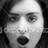

Sample image for expression: fear


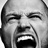

Sample image for expression: angry


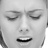

Sample image for expression: neutral


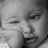

Sample image for expression: sad


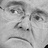

Sample image for expression: disgust


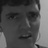

Sample image for expression: happy


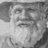

In [14]:
# --- A.1.1: Inspect the data layout ---

def count_exp(path_obj, set_):
    dict_ = {}
    for expression in os.listdir(path_obj):
        dir_ = path_obj / expression
        if os.path.isdir(dir_):
            dict_[expression] = len(os.listdir(dir_))
    df = pd.DataFrame(dict_, index=[set_])
    return df

train_count = count_exp(train_path, 'train')
test_count = count_exp(valid_path, 'test')
print("Train set expression counts:")
print(train_count)
print("\nTest set expression counts:")


for expression in os.listdir(train_path):
    expression_dir = train_path / expression
    if os.path.isdir(expression_dir):
        images = get_image_files(expression_dir)
        if len(images) > 0:
            print(f"Sample image for expression: {expression}")
            display(Image.open(images[0]))

In [15]:
class ExpressionDataset(torch.utils.data.Dataset):
    def __init__(self, path_dir):
        self.samples = []
        for label in os.listdir(path_dir):
            folder = path_dir / label
            if os.path.isdir(folder):
                for img_path in get_image_files(folder):
                    self.samples.append((img_path, expression_to_idx[label]))
        self.transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.Resize((48, 48)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("L")
        return self.transform(image), label

train_ds = ExpressionDataset(train_path)
test_ds = ExpressionDataset(valid_path)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=64)

In [16]:
# --- B.7: Weight Initialization ---
def initialize_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

In [17]:
# --- FCN Model for Expression Classification ---
class FCNExpression(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, 7)
        self.apply(initialize_weights)

    def forward(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [18]:
model = FCNExpression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

FCNExpression(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=128, out_features=7, bias=True)
)

In [19]:
# --- Train Function ---
def train_model(model, train_dl, num_epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)
    criterion = nn.CrossEntropyLoss()
    loss_history = []
    acc_history = []

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            correct += (pred.argmax(1) == yb).sum().item()
            total += xb.size(0)

        scheduler.step()

        epoch_loss = total_loss / total
        epoch_acc = correct / total
        loss_history.append(epoch_loss)
        acc_history.append(epoch_acc)

        print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Accuracy = {epoch_acc:.4f}")

    # Plot loss and accuracy
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs+1), loss_history, label='Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs+1), acc_history, label='Accuracy', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Epoch 1: Loss = 1.8017, Accuracy = 0.2528
Epoch 2: Loss = 1.7831, Accuracy = 0.2557
Epoch 3: Loss = 1.7671, Accuracy = 0.2688
Epoch 4: Loss = 1.7515, Accuracy = 0.2814
Epoch 5: Loss = 1.7340, Accuracy = 0.2929
Epoch 6: Loss = 1.7052, Accuracy = 0.3111
Epoch 7: Loss = 1.6680, Accuracy = 0.3360
Epoch 8: Loss = 1.6219, Accuracy = 0.3621
Epoch 9: Loss = 1.5819, Accuracy = 0.3804
Epoch 10: Loss = 1.5528, Accuracy = 0.3977
Epoch 11: Loss = 1.5264, Accuracy = 0.4126
Epoch 12: Loss = 1.4910, Accuracy = 0.4315
Epoch 13: Loss = 1.4668, Accuracy = 0.4404
Epoch 14: Loss = 1.4482, Accuracy = 0.4486
Epoch 15: Loss = 1.4258, Accuracy = 0.4566
Epoch 16: Loss = 1.4097, Accuracy = 0.4639
Epoch 17: Loss = 1.3938, Accuracy = 0.4705
Epoch 18: Loss = 1.3780, Accuracy = 0.4788
Epoch 19: Loss = 1.3631, Accuracy = 0.4838
Epoch 20: Loss = 1.3483, Accuracy = 0.4906
Epoch 21: Loss = 1.3365, Accuracy = 0.4927
Epoch 22: Loss = 1.3209, Accuracy = 0.5002
Epoch 23: Loss = 1.3091, Accuracy = 0.5038
Epoch 24: Loss = 1.2

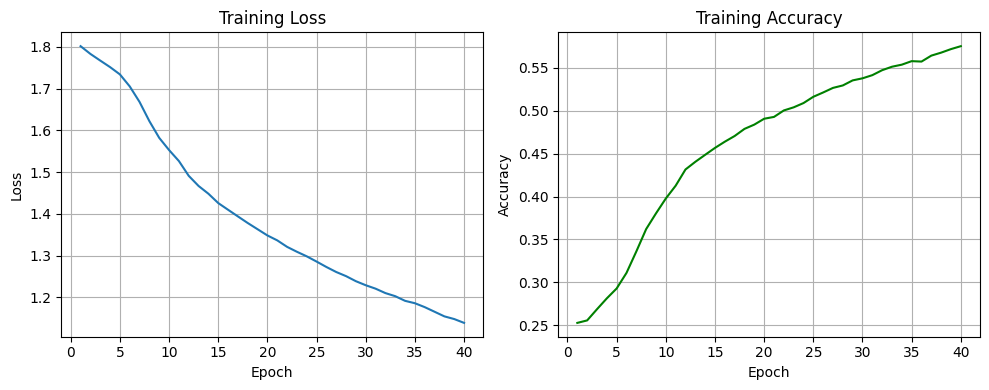

In [20]:
train_model(model, train_dl, num_epochs=40, lr=1e-3)


In [21]:
# --- Save Model ---
torch.save(model.state_dict(), "fcn_expression_model.pth")
import pickle
with open("fcn_expression_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [22]:
# --- Gradio Inference Function ---
def predict_expression(image):
    model.eval()
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(image, scaleFactor=1.1, minNeighbors=5)
    output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    info = []

    if len(faces) == 0:
        return output, "No faces detected"

    for i, (x, y, w, h) in enumerate(faces):
        face = image[y:y+h, x:x+w]
        face = cv2.resize(face, (48, 48))
        face_tensor = transforms.ToTensor()(face).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(face_tensor)
            pred = torch.argmax(logits, dim=1).item()
        label = expression_classes[pred]
        cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(output, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
        info.append(f"Face {i+1}: {label}")

    return output, f"Faces Detected: {len(faces)}\n" + "\n".join(info)

In [23]:
# --- Gradio App ---
demo = gr.Interface(
    fn=predict_expression,
    inputs=gr.Image(type="numpy", label="Upload Image"),
    outputs=[gr.Image(type="numpy", label="Detected Expressions"), gr.Textbox(label="Detection Info")],
    title="Facial Expression Recognition",
    description="Upload an image. The model will detect faces and predict expressions."
)

demo.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9c839d0e1c69e1fa89.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
